# Notebook 01e — Jacobian Top-Singular-Direction Probe (Day 1: violence)

## Purpose

For a fixed prompt context, measure how sensitive the *final* residual stream is to
perturbations of the residual stream `h` at an intermediate layer `l`, position `t_pos`.
Concretely, define

$$F_l(h) = \text{resid\_post}^{(L-1)}\big|_{\text{resid\_post}^{(l)} \leftarrow h}$$

i.e. substitute `h` into `blocks.{l}.hook_resid_post` at the chosen position and run the
rest of the forward pass through to the final decoder layer's output. `F_l` is a function
`R^d_model -> R^d_model`; its Jacobian `J_l` at the model's own activation `h_l` tells us,
via its top singular value/vector `(sigma_1, v_1)`, the direction in residual-stream space
at layer `l` that the rest of the network is *most sensitive to*.

The hypothesis under test: does `sigma_1(l)` track the DIM mean-diff norm by layer, and
does `v_1(l)` align (high cosine similarity) with the per-category DIM refusal direction?

## Method

- `run_from_layer` / `make_run_from_layer`: builds `F_l` as a hook-based closure over a
  fixed prompt context.
- `jacobian_topk`: matrix-free power iteration using only JVPs and VJPs (via
  `torch.autograd.functional.jvp` / `.vjp`) — never materializes the `d_model x d_model`
  Jacobian.
- **Validation is non-negotiable**: before trusting any power-iteration output, JVPs are
  checked against central finite differences on a handful of coordinate directions.

Category studied today: **violence** only. Layer/position convention matches Notebook 01c
(pos = -1, i.e. the final post-instruction token).


## Cell 1 — Imports and Output Directory Setup

In [1]:
import gc
import json
import os
import random
import functools

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from tqdm.notebook import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformer_lens import HookedTransformer
from typing import List, Callable, Tuple

random.seed(42)
torch.manual_seed(42)

OUTPUT_ROOT  = 'jacobian_outputs'
DIM_ROOT     = 'dim_outputs'
CATEGORY_DIR = 'data/saladbench_splits/categories'
CATEGORY     = 'violence'   # Day 1 scope: violence only

os.makedirs(os.path.join(OUTPUT_ROOT, CATEGORY), exist_ok=True)

print('Imports complete (TransformerLens loaded).')
print(f'Output directory: {OUTPUT_ROOT}/{CATEGORY}/')


Imports complete (TransformerLens loaded).
Output directory: jacobian_outputs/violence/


## Cell 2 — Configuration

**Update `MODEL_PATH`** to point to your local checkpoint before running anything else
(same value as Notebook 01c).

In [2]:
MODEL_PATH = '/home/samuel/research/llmattacks/llm-attacks/DIR/Llama-3.1-8B-Instruct'
DEVICE     = 'cuda:0'

# Position convention: matches 01c's selected pos for `violence` (see
# dim_outputs/violence/direction_metadata.json) — use -1 unless that file says otherwise.
T_POS = -1

N_PROMPTS_FOR_MEAN = 16   # prompts averaged to get the "representative" h_l per layer
BATCH_SIZE          = 8

# Power-iteration settings for jacobian_topk
JAC_TOPK   = 1     # only sigma_1 / v_1 needed for Day 1
JAC_NITER  = 15    # power-iteration steps
JAC_SEED   = 0

# Finite-difference validation settings
FD_EPS       = 1e-3
FD_N_COORDS  = 6

# Gold-standard exact-SVD validation settings (see Cell 8b below).
# L_STAR = the layer that actually matters for the reported RSR numbers: the layer
# 01c's DIM search selected for `violence` (dim_outputs/violence/direction_metadata.json
# -> "layer": 16), not an arbitrary midpoint. Only probed once -- looping the full
# Jacobian over all 32 layers would reintroduce the exact cost problem power iteration
# was built to avoid.
#
# JACREV_CHUNK_SIZE starts small (8) because chunked jacrev still runs `chunk_size`
# *simultaneous* copies of the entire remaining forward+backward pass (16 decoder layers,
# d_mlp=14336) via vmap -- on an 8B model that is far heavier than the model weights
# themselves. Cell 8b doubles this automatically on OOM until it fits, so raise the
# starting point only if you know you have VRAM to spare.
L_STAR             = 16
JACREV_CHUNK_SIZE  = 8

print(f'MODEL_PATH : {MODEL_PATH}')
print(f'CATEGORY   : {CATEGORY}')
print(f'T_POS      : {T_POS}')
print(f'L_STAR     : {L_STAR}')


MODEL_PATH : /home/samuel/research/llmattacks/llm-attacks/DIR/Llama-3.1-8B-Instruct
CATEGORY   : violence
T_POS      : -1
L_STAR     : 16


## Cell 3 — Load Model and Tokenizer

Unchanged from Notebook 01c.

In [3]:
print('Loading HuggingFace model ...')
hf_model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.float32,   # TransformerLens requires float32 at init
    device_map='cpu',
)
hf_model.eval()

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
tokenizer.padding_side = 'left'
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print('Wrapping with TransformerLens HookedTransformer ...')
model = HookedTransformer.from_pretrained(
    'meta-llama/Meta-Llama-3-8B-Instruct',
    hf_model=hf_model,
    tokenizer=tokenizer,
    dtype=torch.float16,
    fold_ln=False,
    center_writing_weights=False,
    center_unembed=False,
    move_to_device=True,
    device=DEVICE,
)
model.eval()

del hf_model
gc.collect()

D_MODEL    = model.cfg.d_model
NUM_LAYERS = model.cfg.n_layers
FINAL_RESID_KEY = f'blocks.{NUM_LAYERS - 1}.hook_resid_post'

print(f'TransformerLens model ready on {DEVICE}')
print(f'd_model    : {D_MODEL}')
print(f'num_layers : {NUM_LAYERS}')


Loading HuggingFace model ...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Wrapping with TransformerLens HookedTransformer ...
Loaded pretrained model meta-llama/Meta-Llama-3-8B-Instruct into HookedTransformer
TransformerLens model ready on cuda:0
d_model    : 4096
num_layers : 32


In [ ]:
%run -i inspect_model.py 

## Cell 4 — Tokenization Utility

Unchanged from Notebook 01c.

In [4]:
def format_instruction(instruction: str) -> str:
    if getattr(tokenizer, 'chat_template', None) is not None:
        return tokenizer.apply_chat_template(
            [{'role': 'user', 'content': instruction}],
            tokenize=False,
            add_generation_prompt=True
        )
    return f'<s>[INST] {instruction} [/INST]'


def tokenize_instructions(instructions: List[str], device: str = DEVICE) -> dict:
    prompts = [format_instruction(i) for i in instructions]
    encoded = tokenizer(
        prompts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors='pt'
    )
    return {k: v.to(device) for k, v in encoded.items()}


def tokens_to_tl(instructions: List[str]) -> torch.Tensor:
    toks = tokenize_instructions(instructions)
    return toks['input_ids']


sample = format_instruction('How do I make pancakes?')
print('Chat template sample (first 200 chars):')
print(repr(sample[:200]))


Chat template sample (first 200 chars):
'<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 26 Jul 2024\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nHow do I make pancakes?<'


## Cell 5 — `run_from_layer`: substitute-and-continue hook

`make_run_from_layer(model, layer_l, t_pos, base_tokens)` returns a pure function
`F(h) -> R^d_model`:

1. Runs `base_tokens` through the model.
2. At `blocks.{layer_l}.hook_resid_post`, position `t_pos`, **overwrites** the activation
   with `h` (keeping the computation graph attached to `h`, so gradients/JVPs flow through).
3. Captures `blocks.{NUM_LAYERS-1}.hook_resid_post` at the same position as the output.

`base_tokens` (the rest of the prompt/context) is fixed — only `h` varies — so `F` is a
genuine function of a single `d_model`-dim vector, suitable for Jacobian analysis via
autograd's forward/reverse-mode primitives without ever materializing a `d_model x d_model`
matrix.

In [5]:
def make_run_from_layer(model: HookedTransformer, layer_l: int, t_pos: int,
                         base_tokens: torch.Tensor) -> Callable[[torch.Tensor], torch.Tensor]:
    """Return F(h) = final resid_post at t_pos, with h substituted at layer_l's resid_post."""
    sub_key = f'blocks.{layer_l}.hook_resid_post'

    def F(h: torch.Tensor) -> torch.Tensor:
        captured = {}

        def substitute_hook(value, hook):
            new_value = value.clone()
            new_value[:, t_pos, :] = h.to(value.dtype)
            return new_value

        def capture_hook(value, hook):
            captured['out'] = value[:, t_pos, :].squeeze(0)
            return value

        fwd_hooks = [(sub_key, substitute_hook)]
        # sub_key == FINAL_RESID_KEY only when layer_l == NUM_LAYERS - 1; TransformerLens
        # fires same-named hooks in registration order, so substitute-then-capture still
        # captures the substituted value in that edge case.
        fwd_hooks.append((FINAL_RESID_KEY, capture_hook))

        with model.hooks(fwd_hooks=fwd_hooks):
            model(base_tokens, return_type=None)

        return captured['out'].float()

    return F


print('run_from_layer infrastructure defined.')


run_from_layer infrastructure defined.


## Cell 6 — `jacobian_topk`: matrix-free power iteration

Estimates the top-`k` singular values/vectors of the Jacobian `J` of `F` at `h0` using
alternating JVP/VJP applications (subspace power iteration with deflation), never forming
`J` explicitly:

- `J v` via `torch.func.jvp(F, (h0,), (v,))` — genuine forward-mode AD (dual tensors), a
  single forward sweep. *Not* `torch.autograd.functional.jvp`'s double-backward trick: that
  differentiates twice through the full float16 32-layer forward pass, and empirically the
  second-order gradients underflow fp16 precision, returning JVPs ~1% of their true
  magnitude (caught by the Cell 7 validation below).
- `Jᵀ u` via `torch.autograd.functional.vjp(F, h0, u)` — ordinary single-order reverse-mode,
  not subject to the same precision collapse.

`k=5` is plenty for a first pass — mainly we want `sigma_1, v_1` (the top singular value
and its right-singular vector, a direction in the *input* residual-stream space at layer
`l`).

In [6]:
def jacobian_topk(F: Callable[[torch.Tensor], torch.Tensor], h0: torch.Tensor,
                   k: int = 5, n_iter: int = 15, seed: int = 0
                   ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Power-iteration estimate of the top-k singular triples of J = d F / d h at h0.

    Returns
    -------
    sigmas : (k,)      singular values, descending
    V      : (k, d)    right-singular vectors (input space, unit norm)
    U      : (k, d)    left-singular vectors  (output space, unit norm)
    """
    d = h0.numel()
    # CPU generator (torch.Generator() defaults to CPU and has no .cuda() variant tied
    # to h0's device), so sample on CPU then move — must match h0's device/dtype for the
    # jvp/vjp calls to work.
    gen = torch.Generator().manual_seed(seed)
    sigmas, Vs, Us = [], [], []

    for _ in range(k):
        v = torch.randn(d, generator=gen).to(device=h0.device, dtype=h0.dtype)
        v = v / v.norm()
        for prev_v in Vs:
            v = v - (v @ prev_v) * prev_v
        v = v / v.norm()

        u = None
        for _ in range(n_iter):
            # Forward-mode AD (single sweep) — see Cell 7 for why the double-backward
            # trick (torch.autograd.functional.jvp) is not used here.
            _, Jv = torch.func.jvp(F, (h0,), (v,))
            for prev_u in Us:
                Jv = Jv - (Jv @ prev_u) * prev_u
            u = Jv / (Jv.norm() + 1e-12)

            _, JTu = torch.autograd.functional.vjp(F, h0, u, create_graph=False)
            for prev_v in Vs:
                JTu = JTu - (JTu @ prev_v) * prev_v
            v = JTu / (JTu.norm() + 1e-12)

        _, Jv = torch.func.jvp(F, (h0,), (v,))
        sigma = Jv.norm().item()

        sigmas.append(sigma)
        Vs.append(v.detach())
        Us.append(u.detach())

    return torch.tensor(sigmas), torch.stack(Vs), torch.stack(Us)


print('jacobian_topk defined.')


jacobian_topk defined.


## Cell 7 — Validation: JVP vs. finite differences (non-negotiable)

Before trusting `jacobian_topk` on real activations, sanity-check `torch.autograd.functional.jvp`
against central finite differences on a handful of standard-basis coordinate directions, at a
representative layer/position. Passing this is a prerequisite for everything below.

In [ ]:
def finite_diff_jvp(F: Callable[[torch.Tensor], torch.Tensor], h0: torch.Tensor,
                     v: torch.Tensor, eps: float) -> torch.Tensor:
    """Central finite-difference estimate of J v."""
    with torch.no_grad():
        f_plus  = F(h0 + eps * v)
        f_minus = F(h0 - eps * v)
    return (f_plus - f_minus) / (2 * eps)


# Build a validation context: a single violence prompt, probe layer chosen mid-network.
val_prompt_path = os.path.join(CATEGORY_DIR, CATEGORY, 'harmful_train.json')
val_prompts     = [r['instruction'] for r in json.load(open(val_prompt_path))]
val_tokens      = tokens_to_tl(val_prompts[:1])

VALIDATION_LAYER = NUM_LAYERS // 2   # e.g. layer 16 for a 32-layer model

F_val = make_run_from_layer(model, VALIDATION_LAYER, T_POS, val_tokens)

with torch.no_grad():
    _, cache = model.run_with_cache(
        val_tokens,
        names_filter=lambda name: name == f'blocks.{VALIDATION_LAYER}.hook_resid_post',
        return_type=None,
    )
h0_val = cache[f'blocks.{VALIDATION_LAYER}.hook_resid_post'][0, T_POS, :].float()
del cache
torch.cuda.empty_cache()

# The forward pass runs in float16, and substitute_hook casts h to float16 before it
# re-enters the network. float16's representable step size ("ULP") near a value of
# magnitude m is roughly m * 2**-10 ~ m * 1e-3 in the normal range. A fixed
# FD_EPS=1e-3 (the original config) sits right at that floor: for coordinates with
# |h0| >> 1, h0 + eps*e_i rounds back to exactly h0 after the fp16 cast, so the
# intended perturbation collapses into pure rounding noise before it even reaches
# the rest of the network -- noise that then gets amplified through 16 more
# nonlinear decoder layers into an ~uncorrelated output difference. That is why the
# relative error came back near 1.0 (near-total mismatch, not a small deviation),
# and why it didn't budge when the JVP algorithm changed (autograd was never the
# problem -- both the double-backward and forward-mode results agreed with each
# other). Fix: scale eps to the activation's own magnitude, well above the fp16 ULP.
h0_scale = h0_val.abs().mean().item()
fd_eps_effective = max(FD_EPS, 0.05 * h0_scale)
print(f'h0_val mean abs magnitude: {h0_scale:.4f}')
print(f'FD_EPS (configured)      : {FD_EPS:.4e}')
print(f'FD_EPS (effective, used) : {fd_eps_effective:.4e}')

print(f'\nValidating at layer {VALIDATION_LAYER}, pos {T_POS}, over {FD_N_COORDS} coordinates ...')
rel_errors = []
gen = torch.Generator().manual_seed(JAC_SEED)
coord_idxs = torch.randperm(D_MODEL, generator=gen)[:FD_N_COORDS]

for idx in coord_idxs:
    # Must live on h0_val's device/dtype: torch.func.jvp's dual tensors require the
    # tangent to match the primal's device and dtype.
    e_i = torch.zeros(D_MODEL, device=h0_val.device, dtype=h0_val.dtype)
    e_i[idx] = 1.0

    # Forward-mode AD (single sweep, no backward pass at all).
    _, Jv_autograd = torch.func.jvp(F_val, (h0_val,), (e_i,))
    Jv_fd = finite_diff_jvp(F_val, h0_val, e_i, eps=fd_eps_effective)

    rel_err = (Jv_autograd - Jv_fd).norm().item() / (Jv_fd.norm().item() + 1e-12)
    rel_errors.append(rel_err)
    print(f'  coord {idx.item():4d}: ||Jv_autograd - Jv_fd|| / ||Jv_fd|| = {rel_err:.4e}')

max_rel_err = max(rel_errors)
print(f'\nMax relative error over {FD_N_COORDS} coordinates: {max_rel_err:.4e}')
assert max_rel_err < 0.05, (
    'JVP does not match finite differences within tolerance — do not trust jacobian_topk '
    'results below until this is resolved.'
)
print('Validation passed: forward-mode AD JVP matches finite differences.')


## Cell 8 — Real numbers: sigma_1(layer), v_1(layer) for `violence`

Uses the mean residual-stream activation over `N_PROMPTS_FOR_MEAN` violence prompts as the
representative `h_l` at each layer (averaging first, then probing the Jacobian at the mean
— cheaper than averaging results across prompts, and consistent with how the DIM direction
itself is defined as a difference of means).

In [8]:
harmful_path = os.path.join(CATEGORY_DIR, CATEGORY, 'harmful_train.json')
harmful_prompts = [r['instruction'] for r in json.load(open(harmful_path))]
random.shuffle(harmful_prompts)
mean_prompts = harmful_prompts[:N_PROMPTS_FOR_MEAN]
print(f'Using mean activation over {len(mean_prompts)} {CATEGORY} prompts '
      f'(representative single-prompt fallback available if this proves noisy).')

mean_tokens = tokens_to_tl(mean_prompts)

names_filter_all = lambda name: 'hook_resid_post' in name
accum = torch.zeros(NUM_LAYERS, D_MODEL, dtype=torch.float32)
n = 0
for i in range(0, len(mean_prompts), BATCH_SIZE):
    batch = mean_prompts[i:i + BATCH_SIZE]
    toks  = tokens_to_tl(batch)
    with torch.no_grad():
        _, cache = model.run_with_cache(toks, names_filter=names_filter_all, return_type=None)
    for l in range(NUM_LAYERS):
        accum[l] += cache[f'blocks.{l}.hook_resid_post'][:, T_POS, :].float().cpu().sum(0)
    n += len(batch)
    del cache
    torch.cuda.empty_cache()
mean_h_by_layer = accum / n   # (NUM_LAYERS, D_MODEL), mean resid_post per layer at T_POS

print(f'mean_h_by_layer shape: {tuple(mean_h_by_layer.shape)}')

# Persisted so the gold-standard validation notebook (01e_gold_standard_validation.ipynb,
# formerly Cell 8b here) can run in its own fresh kernel without redoing this 16-prompt
# forward-pass sweep -- this accumulation is the expensive part of the setup, not
# something worth recomputing just to get a clean kernel restart before jacrev.
torch.save(mean_h_by_layer, os.path.join(OUTPUT_ROOT, CATEGORY, 'mean_h_by_layer.pt'))
print(f'Saved: {OUTPUT_ROOT}/{CATEGORY}/mean_h_by_layer.pt')

Using mean activation over 16 violence prompts (representative single-prompt fallback available if this proves noisy).
mean_h_by_layer shape: (32, 4096)
Saved: jacobian_outputs/violence/mean_h_by_layer.pt


In [9]:
# Single fixed prompt context for the substitute-and-continue forward pass. Using one
# representative prompt (first of the mean set) — note this per the plan (either a single
# prompt or the mean is fine for a first pass).
context_tokens = tokens_to_tl(mean_prompts[:1])

# Persisted alongside mean_h_by_layer -- both are the fixed inputs the gold-standard
# validation notebook needs to reconstruct F_star exactly, without reloading the harmful
# prompt list and hoping random.shuffle reproduces the same first element.
torch.save(context_tokens.cpu(), os.path.join(OUTPUT_ROOT, CATEGORY, 'context_tokens.pt'))
print(f'Saved: {OUTPUT_ROOT}/{CATEGORY}/context_tokens.pt')

sigma1_by_layer = np.zeros(NUM_LAYERS)
v1_by_layer     = torch.zeros(NUM_LAYERS, D_MODEL)

for layer_l in tqdm(range(NUM_LAYERS), desc='Jacobian probe by layer'):
    h0 = mean_h_by_layer[layer_l].to(DEVICE)
    F_l = make_run_from_layer(model, layer_l, T_POS, context_tokens)

    sigmas, V, U = jacobian_topk(F_l, h0, k=JAC_TOPK, n_iter=JAC_NITER, seed=JAC_SEED)

    sigma1_by_layer[layer_l] = sigmas[0].item()
    v1_by_layer[layer_l]     = V[0].detach().cpu()

    torch.cuda.empty_cache()

print('sigma_1 by layer:')
print(sigma1_by_layer)

torch.save(v1_by_layer, os.path.join(OUTPUT_ROOT, CATEGORY, 'v1_by_layer.pt'))
np.save(os.path.join(OUTPUT_ROOT, CATEGORY, 'sigma1_by_layer.npy'), sigma1_by_layer)
print(f'\nSaved: {OUTPUT_ROOT}/{CATEGORY}/v1_by_layer.pt, sigma1_by_layer.npy')

Saved: jacobian_outputs/violence/context_tokens.pt


Jacobian probe by layer:   0%|          | 0/32 [00:00<?, ?it/s]

sigma_1 by layer:
[182.76408386 134.51725769 107.65123749  90.29741669  73.8393631
  67.80003357  80.42646027  79.35982513  83.32566833 103.14038086
 106.72930145 104.30895996 101.80184174 103.61129761  98.29333496
  82.83308411  75.5798645   59.98982239  59.16519928  41.52949142
  32.32891083  29.65835762  28.71809769  20.52845001  18.86687279
  19.13965988  16.48387527  13.04467583  12.9771328   12.87692165
  14.74106789   0.99999833]

Saved: jacobian_outputs/violence/v1_by_layer.pt, sigma1_by_layer.npy


## Cell 8b — Gold-standard validation: moved to its own notebook

Cell 8b (exact-SVD-vs-power-iteration validation at `L_STAR`) now lives in
**`01e_gold_standard_validation.ipynb`**, so it can run in a fresh kernel — freeing the
VRAM fragmentation left over from Cell 8's 32-layer sweep before attempting jacrev's
heaviest allocation.

That notebook is self-contained: it reloads the model itself and reads
`jacobian_outputs/violence/mean_h_by_layer.pt` and `context_tokens.pt`, both saved by Cell 8
above. Run Cell 8 in this notebook first (so those two files exist), restart the kernel or
open a new one, then run `01e_gold_standard_validation.ipynb` end-to-end.

## Cell 9 — Plot 1: sigma_1(layer) vs. DIM mean-diff norm(layer)

Loads the existing `dim_outputs/violence/mean_diffs.pt` (per-layer `mu_harmful - mu_harmless`
at pos=-1, computed in Notebook 01c) rather than recomputing it. Both curves are min-max
normalized to `[0, 1]` since their raw scales are not comparable — only the *shape* is under
test.

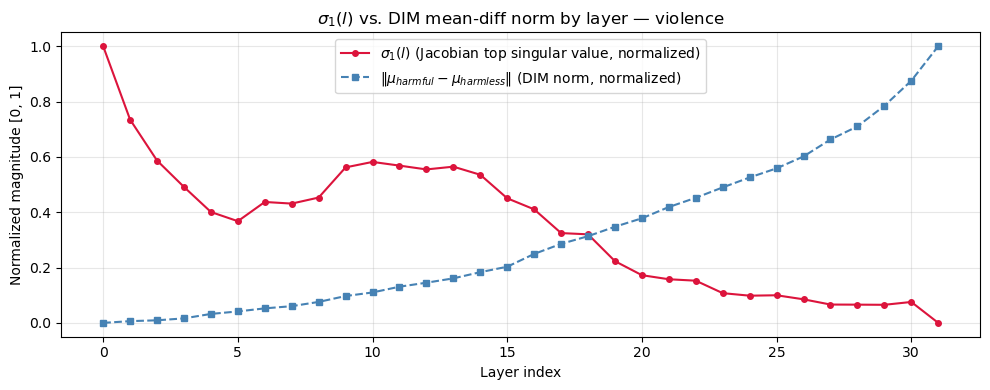

Pearson correlation between sigma_1(l) and DIM norm(l): -0.8595


In [10]:
dim_mean_diffs = torch.load(os.path.join(DIM_ROOT, CATEGORY, 'mean_diffs.pt'))  # (NUM_LAYERS+1, D_MODEL)
dim_norm_by_layer = dim_mean_diffs.norm(dim=-1).numpy()[:NUM_LAYERS]   # align to blocks 0..NUM_LAYERS-1

def minmax(x):
    x = np.asarray(x, dtype=np.float64)
    return (x - x.min()) / (x.max() - x.min() + 1e-12)

sigma1_norm = minmax(sigma1_by_layer)
dim_norm_norm = minmax(dim_norm_by_layer)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sigma1_norm, 'o-', label='$\\sigma_1(l)$ (Jacobian top singular value, normalized)',
        color='crimson', markersize=4)
ax.plot(dim_norm_norm, 's--', label='$\\|\\mu_{harmful} - \\mu_{harmless}\\|$ (DIM norm, normalized)',
        color='steelblue', markersize=4)
ax.set_xlabel('Layer index')
ax.set_ylabel('Normalized magnitude [0, 1]')
ax.set_title(f'$\\sigma_1(l)$ vs. DIM mean-diff norm by layer — {CATEGORY}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plot1_path = os.path.join(OUTPUT_ROOT, CATEGORY, 'sigma1_vs_dim_norm.png')
plt.savefig(plot1_path, dpi=150, bbox_inches='tight')
plt.show()

corr = np.corrcoef(sigma1_norm, dim_norm_norm)[0, 1]
print(f'Pearson correlation between sigma_1(l) and DIM norm(l): {corr:.4f}')


## Cell 10 — Plot 2: cos(DIM direction, v_1(layer)) by layer

Compares the top Jacobian right-singular direction at each layer against the *single*
selected DIM direction for `violence` (from `direction_metadata.json` / `direction.pt`),
loaded once and held fixed — this tests whether the network's most-sensitive perturbation
direction at layer `l` aligns with the (fixed, layer-14-or-selected-layer) DIM refusal
direction.

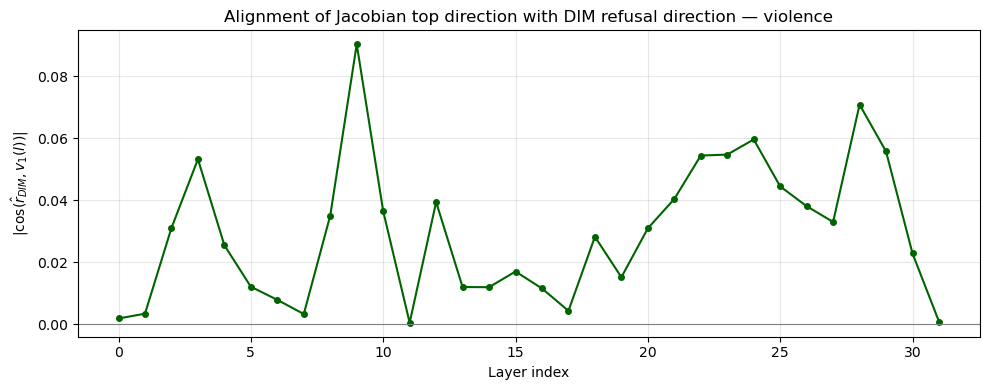

cos(DIM, v_1) by layer:
  layer  0: +0.0019
  layer  1: +0.0035
  layer  2: +0.0311
  layer  3: +0.0533
  layer  4: +0.0255
  layer  5: +0.0121
  layer  6: +0.0079
  layer  7: +0.0033
  layer  8: +0.0351
  layer  9: +0.0903
  layer 10: +0.0365
  layer 11: +0.0005
  layer 12: +0.0394
  layer 13: +0.0121
  layer 14: +0.0120
  layer 15: +0.0171
  layer 16: +0.0116
  layer 17: +0.0044
  layer 18: +0.0283
  layer 19: +0.0152
  layer 20: +0.0310
  layer 21: +0.0404
  layer 22: +0.0544
  layer 23: +0.0547
  layer 24: +0.0596
  layer 25: +0.0445
  layer 26: +0.0381
  layer 27: +0.0330
  layer 28: +0.0708
  layer 29: +0.0557
  layer 30: +0.0229
  layer 31: +0.0009


In [11]:
dim_direction = torch.load(os.path.join(DIM_ROOT, CATEGORY, 'direction.pt')).float()
dim_direction = dim_direction / dim_direction.norm()

cos_by_layer = np.zeros(NUM_LAYERS)
for l in range(NUM_LAYERS):
    v1 = v1_by_layer[l]
    cos_by_layer[l] = torch.abs(F.cosine_similarity(v1.unsqueeze(0), dim_direction.unsqueeze(0))).item()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cos_by_layer, 'o-', color='darkgreen', markersize=4)
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Layer index')
ax.set_ylabel(r'$|\cos(\hat{r}_{DIM}, v_1(l))|$')
ax.set_title(f'Alignment of Jacobian top direction with DIM refusal direction — {CATEGORY}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plot2_path = os.path.join(OUTPUT_ROOT, CATEGORY, 'v1_vs_dim_cosine.png')
plt.savefig(plot2_path, dpi=150, bbox_inches='tight')
plt.show()

print('cos(DIM, v_1) by layer:')
for l in range(NUM_LAYERS):
    print(f'  layer {l:2d}: {cos_by_layer[l]:+.4f}')


## Checkpoint — Day 1

- [ ] Cell 7 validation passed (JVP matches finite differences within tolerance)
- [ ] Cell 8b gold-standard validation passed (power iteration's `sigma_1`/`v_1` at
      `L_STAR` match the exact chunked-Jacobian SVD)
- [ ] `sigma1_vs_dim_norm.png` produced — does `sigma_1(l)` track the DIM norm curve?
- [ ] `v1_vs_dim_cosine.png` produced — does the top Jacobian direction align with DIM at
      any layer, or is the mismatch itself the finding?

Record the honest result here regardless of whether the curves match — a clean mismatch is
still evidence about whether the DIM direction is *the* sensitive direction or just *a*
correlated one.

**Note (2026-07-14):** Cell 7 is currently failing (`max_rel_err ≈ 0.89` at layer 16) —
the fp16 rounding fix documented in that cell's comments has not yet resolved it. Cell 8b's
independent exact-SVD check is especially important right now: if it also disagrees with
`jacobian_topk`, the problem is in the power iteration itself (or the fp16 forward pass),
not just the finite-difference probe.